# Física Computacional 2 - Caos no pêndulo não linear

## 1. O pêndulo não-linear

Considere um pêndulo consistindo de uma haste leve de comprimento $l$ e uma massa pontual $m$ fixada em sua extremidade mais baixa. Assuma que o pêndulo está confinado a mover-se no plano vertical, sob ação de uma força externa $f_d$ e de uma força resistiva $f_r$ como mostrado na figura acima. O movimento do pêndulo é descrito pela equação de Newton ao longo da direção tangencial do movimento circular da massa pontual,

$$
ma_t=f_g+f_d+f_r, \;\;\;\;\;\; (1)
$$
onde $f_g=-mg\sin\theta$ é a contribuição da gravidade na direção do movimento e $\theta$ o ângulo feito pela haste em relação à linha vertical e $a_t=l\frac{d^2\theta}{dt^2}$ é a acelaração ao longo da direção tangencial.

Primeiramente considere que não há força externa, ou seja, $f_d=0$ e que a força resistiva é desprezível, $f_r=0$. Neste caso, obtemos a seguinte equação de movimento,

$$
\frac{d^2 \theta}{dt^2}=-\frac{g}{l}\sin\theta. \;\;\;\;\;\; (2)
$$
Portanto, consideramos o pêndulo não-linear sem atrito e sem força externa, fora a gravitacional. Como não há como adicionar ou remover energia deste sistema, a energia mecânica total é conservada e o pêndulo executa um movimento periódico. O período, no entanto não é independente da amplitude. Assuma que começamos o movimento com um certo deslocamento angular $\theta(t=0)=\theta_0$ de onde o pêndulo é solto, $\frac{d\theta(t=0)}{dt}=0.$ O período pode ser expresso como,

$$
T(\theta_0)=4\sqrt{\frac{ l}{g}}K(\sin(\theta_0/2)), \;\;\;\;\;\;\;\;\;\;\;\; (3)
$$
onde $K$ é uma integral elíptica dada por,
$$
K(a)=\int_0^{\pi/2}\frac{dx}{\sqrt{1-a^2\sin^2x}}.
$$

Para resolver numericamente o problema, podemos transformar a equação diferencial de segunda ordem em duas de primeira ordem com a introdução de uma variável auxiliar (a velocidade angular) $\omega(t)=\frac{d\theta}{dt}$,

$$
\frac{d\theta(t)}{dt}=\omega(t) \\
\frac{d\omega(t)}{dt}=-\frac{g}{l}\sin\theta
$$




---
<font color='red'> EXERCÍCIO 1 </font> Resolva as equações de movimento do pêndulo não-linear sem atrito e sem força externa numericamente pelo método de Runge-Kutta de 4a. ordem. Faça um gráfico de $\theta$ versus o tempo para dois valores inicais de $\theta(0)=\pi/2$ e $\theta(0)=0.9\pi$ com $\omega(0)=0$, considere o tempo final $t=10$s. Verifique que o período do movimento depende da amplitude inicial. Utilize $g=9.8{\rm m/s^2}$ e $l=1$m.

----

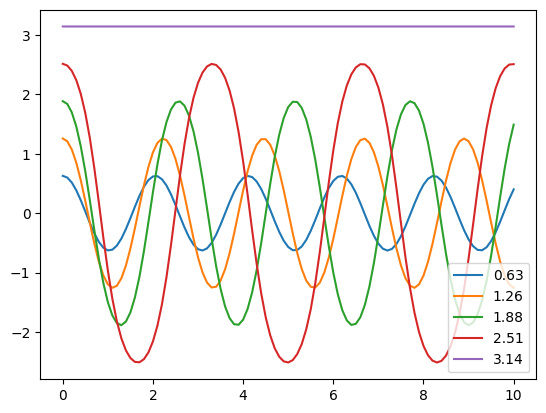

In [7]:
import numpy as np
import matplotlib.pyplot as plt

g=9.8 #aceleração em m/s**2
l=1 # comprimento do pêndulo em metros
tf=10 #tempo final em segundos

def F(t,X):
  f=np.zeros(2)
  f[0]=X[1]
  f[1]=-g/l*np.sin(X[0])
  return f

def RK4(t,X,h):
  K1=F(t,X)
  K2=F(t+0.5*h,X+0.5*h*K1)
  K3=F(t+0.5*h,X+0.5*h*K2)
  K4=F(t+h,X+h*K3)
  return X+h/6*(K1+2*K2+2*K3+K4)
N=100
t=np.linspace(0,tf,N+1)
h=tf/N


for j in range(5):
  theta0=(j+1)*0.2*np.pi
  #condições iniciais
  theta=np.zeros(N+1)
  omega=np.zeros(N+1)
  theta[0]=theta0
  omega[0]=0.
  X=np.zeros(2)#;X=np.array([theta[0],omega[0]])
  X[0]=theta[0]
  X[1]=omega[0]
  for i in range(N):
    X=RK4(t[i],X,h)
    theta[i+1]=X[0]
    omega[i+1]=X[1]
  plt.plot(t,theta,label=str(round(theta0,2)))


plt.legend()
plt.show()








## 2. Caos no pêndulo dissipativo e forçado

Agora vamos assumir uma força externa periódica dada por

$$
f_d=f_0\sin(\Omega t),
$$
e uma força resistiva $f_r=-kv$, onde $v=l\frac{d\theta}{dt}$ é a velocidade da massa e $\kappa$ é um parâmetro de resistência positivo e constante. Obtemos assim as seguintes equações,

$$
\frac{d\theta(t)}{dt}=\omega(t) \\
\frac{d\omega(t)}{dt}=-\frac{g}{l}\sin\theta-q\omega+b\sin(\Omega t),
$$
onde $q=\kappa/m$ e $b=f_0/(ml)$.


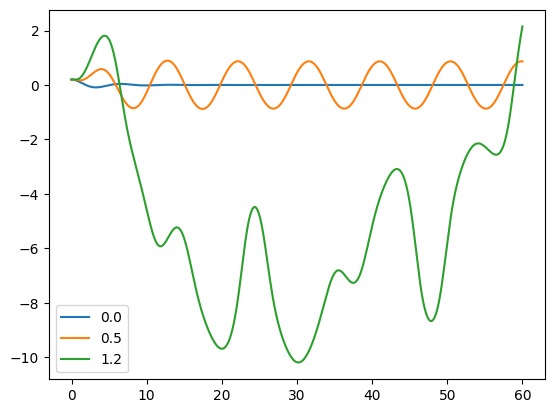

In [5]:
import numpy as np
import matplotlib.pyplot as plt

g=9.8 #aceleração em m/s**2
l=9.8 # comprimento do pêndulo em metros
tf=60 #tempo final em segundos
q=0.5
Omega=2/3

def F(t,X):
  f=np.zeros(2)
  f[0]=X[1]
  f[1]=-g/l*np.sin(X[0])-q*X[1]+b*np.sin(Omega*t)
  return f

def RK4(t,X,h):
  K1=F(t,X)
  K2=F(t+0.5*h,X+0.5*h*K1)
  K3=F(t+0.5*h,X+0.5*h*K2)
  K4=F(t+h,X+h*K3)
  return X+h/6*(K1+2*K2+2*K3+K4)
N=800
t=np.linspace(0,tf,N+1)
h=tf/N


for b in (0.,0.5,1.2):
  #condições iniciais
  theta=np.zeros(N+1)
  omega=np.zeros(N+1)
  theta[0]=0.2
  omega[0]=0.
  X=np.zeros(2)#;X=np.array([theta[0],omega[0]])
  X[0]=theta[0]
  X[1]=omega[0]
  for i in range(N):
    X=RK4(t[i],X,h)
    theta[i+1]=X[0]
    omega[i+1]=X[1]
  plt.plot(t,theta,label=str(round(b,2)))


plt.legend()
plt.show()

### 2.1 Sensibilidade às condições iniciais

Uma das características mais marcantes do comportamento caótico é a sensibilidade às condições iniciais. Duas condições iniciais muito próximas acabam divergindo com o passar do tempo no regime caótico. Por exemplo, se $\theta_1$ e $\theta_2$ são ângulos iniciais muito próximos com o mesmo valor da velocidade angular inicial e $\Delta \theta=|\theta_2-\theta_1|$ é a diferença entre esses ângulos, temos

$$
\Delta \theta \approx {\rm e}^{\lambda t},
$$
onde $\lambda$ é conhecido como expoente de Lyapunov. No regime caótico, o expoente de Lyapunov é possitivo, o que significa que as trajetórias divergem com o passar do tempo.

Como não podemos nunca garantir precisão infinita nas condições iniciais, bem como dos parâmetros, de qualquer sistema, isso significa que o futuro de um sistema caótico é essencialmente imprevisível. Em outras palavras, um sistema pode obedecer equações determinísticas da Física, mas ainda exibir um comportamento imprevisível devido à sensibilidade às condições iniciais.


---
<font color='red'> EXERCÍCIO 2 </font> Novamente, resolva as equações de movimento do pêndulo não-linear com atrito e com força externa numericamente pelo método de Runge-Kutta de 4a. ordem. Considere duas condições iniciais bem próximas $\theta_1(0)=0.2$ e $\theta_2(0)=0.2001$ ($\omega(0)=0$) e faça o gráfico semi-logaritmico da diferença $\Delta \theta=|\theta_2-\theta_1|$ em função do tempo para dois valores de amplitude $b=0.5$ e $b=1.2$. Utilize os mesmos parâmetros do exercício 2.

----

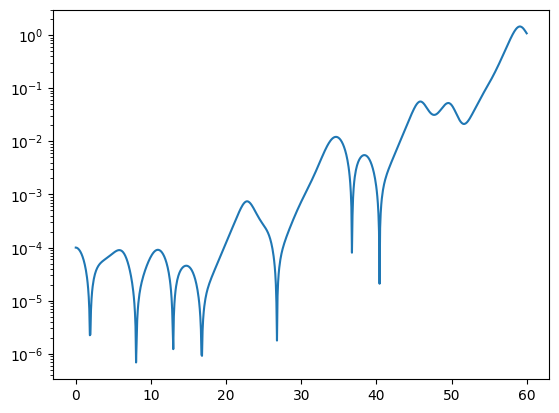

In [4]:
import numpy as np
import matplotlib.pyplot as plt

g=9.8 #aceleração em m/s**2
l=9.8 # comprimento do pêndulo em metros
tf=60 #tempo final em segundos
q=0.5
Omega=2/3
b=1.2

def F(t,X):
  f=np.zeros(2)
  f[0]=X[1]
  f[1]=-g/l*np.sin(X[0])-q*X[1]+b*np.sin(Omega*t)
  return f

def RK4(t,X,h):
  K1=F(t,X)
  K2=F(t+0.5*h,X+0.5*h*K1)
  K3=F(t+0.5*h,X+0.5*h*K2)
  K4=F(t+h,X+h*K3)
  return X+h/6*(K1+2*K2+2*K3+K4)
N=800
t=np.linspace(0,tf,N+1)
h=tf/N

#condições iniciais
theta1=np.zeros(N+1)
omega1=np.zeros(N+1)
theta2=np.zeros(N+1)
omega2=np.zeros(N+1)
deltatheta=np.zeros(N+1)

theta1[0]=0.2
omega1[0]=0.
theta2[0]=0.2001
omega2[0]=0.
deltatheta[0]=abs(theta2[0]-theta1[0])
X1=np.zeros(2)
X1[0]=theta1[0]
X1[1]=omega1[0]
X2=np.zeros(2)
X2[0]=theta2[0]
X2[1]=omega2[0]
for i in range(N):
  X1=RK4(t[i],X1,h)
  X2=RK4(t[i],X2,h)
  theta1[i+1]=X1[0]
  omega1[i+1]=X1[1]
  theta2[i+1]=X2[0]
  omega2[i+1]=X2[1]
  deltatheta[i+1]=abs(theta2[i+1]-theta1[i+1])

#deltatheta=abs(theta2-theta1)
plt.yscale("log")
plt.plot(t,deltatheta)
plt.show()

---
<font color='red'> EXERCÍCIO 3 </font> Uma outra forma de observar a dinâmica de sistemas caóticos é graficando o espaço de fases. Ao invés de fazer o gráfico do ângulo $\theta$ em função do tempo, faça agora gráficos de $\omega$ em função de $\theta$. Considere os parâmetros dos programas anteriores e calcule o espaço de fases para $b=0.5$ e $b=1.2$.


----

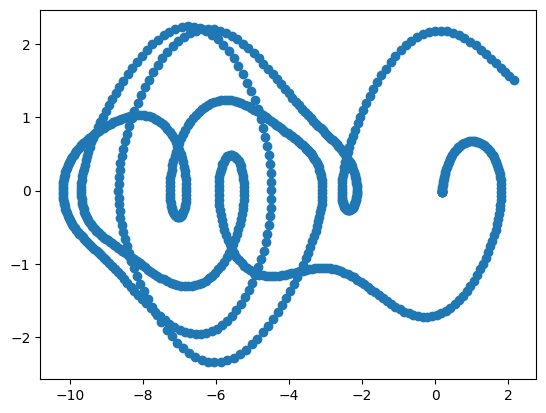

In [2]:
import numpy as np
import matplotlib.pyplot as plt

g=9.8 #aceleração em m/s**2
l=9.8 # comprimento do pêndulo em metros
tf=60 #tempo final em segundos
q=0.5
Omega=2/3
b=1.2

def F(t,X):
  f=np.zeros(2)
  f[0]=X[1]
  f[1]=-g/l*np.sin(X[0])-q*X[1]+b*np.sin(Omega*t)
  return f

def RK4(t,X,h):
  K1=F(t,X)
  K2=F(t+0.5*h,X+0.5*h*K1)
  K3=F(t+0.5*h,X+0.5*h*K2)
  K4=F(t+h,X+h*K3)
  return X+h/6*(K1+2*K2+2*K3+K4)
N=800
t=np.linspace(0,tf,N+1)
h=tf/N

#condições iniciais
theta1=np.zeros(N+1)
omega1=np.zeros(N+1)


theta1[0]=0.2
omega1[0]=0.

X1=np.zeros(2)
X1[0]=theta1[0]
X1[1]=omega1[0]

for i in range(N):
  X1=RK4(t[i],X1,h)
  theta1[i+1]=X1[0]
  omega1[i+1]=X1[1]



plt.scatter(theta1,omega1)
plt.show()